Normalized weights by taking each weight individually and divided by the sum of all weights.
I started with zero portfolio value ie. no stocks puchased and then purchased the required stocks from the capital in hand according to the weights calculated earlier.
I chose an error threshhold of 5% for simplicity and whenever the RMSE of weights varied by more than the threshhold the code forces a  rebalance.
It takes account of the fee and deducts it from the capital inhand. So after withdrawing our money we can only invest (our money - fee deducted).

In [97]:
import pandas as pd

In [99]:
#defiing a function to determine whether we need to rebalance our portfolio
def should_rebalance(target_weights, current_weights, threshold=0.05):
    #normalizing all values
    target = target_weights / target_weights.sum()
    current = current_weights / current_weights.sum()

    #RMSE calculation to check if over threshhold of 5%
    error = ((target - current) ** 2).mean() ** 0.5
    #if error is more than threshhold return TRUE
    return error > threshold


In [101]:
#setting up initial conditions
initial_capital = 100000
fee_rate = 0.001


In [137]:
#load the combined_close_prices data and make the date column at date type
close_prices = pd.read_csv('combined_close_prices.csv', parse_dates=['date'])

#set date column as index to use each row's data based on trading day
if 'date' in close_prices.columns:
    close_prices = close_prices.set_index('date')

#drop any columns that are not names of stocks
#select columns that correspond to stocks
stock_columns = [col for col in close_prices.columns if col.upper() in weights.index.str.upper()]
#keep only stock columns
close_prices = close_prices[stock_columns]

#now we convert all values to floats from strings and drop rows that have all values NAN
close_prices = close_prices.apply(pd.to_numeric, errors='coerce').dropna(how='all')

#load the metrics csv file containing assigned weights of the stocks we calculated in part 2
metrics_df = pd.read_csv('metrics_df.csv', index_col=0)
#making a series of the weights we determined in the previous part
weights = metrics_df['weight']

#create empty list to store the portfolio values of each day
portfolio_values = []
#make a series of the number of shares of each stock. we have started with zero shares of each and
#the entire capital in our hand
shares_held = pd.Series(0, index=close_prices.columns)
capital = initial_capital

close_prices = close_prices.copy()

#we'll use a for loop to iterate through each trading day and change prices accordingly
#we are using enumerate to force a rebalance on the first day 
for i, date in enumerate(close_prices.index):
    prices_today = close_prices.loc[date]

    #align prices to the shares to ensure the correct multiplication later on
    prices_today = prices_today[shares_held.index]

    #calculating value of the portfolio
    position_value = shares_held * prices_today
    total_value = position_value.sum()

    #calculating current weights
    if total_value == 0:
        current_weights = weights
    else:
        current_weights = position_value / total_value

    #force rebalance on day 0 or if RMSE threshold is exceeded
    if i == 0 or should_rebalance(weights, current_weights, threshold=0.05):
        fee = total_value * fee_rate
        #reduce capital by deducting fee
        capital = total_value - fee if total_value > 0 else capital

        allocation = capital * weights
        shares_held = allocation / prices_today

    # Append portfolio value
    portfolio_values.append((shares_held * prices_today).sum())

In [138]:
#Moving on to part 4
#calculating buy and hold returns for all stock by taking day one and day final values
buy_and_hold_returns = close_prices.iloc[-1] / close_prices.iloc[0] - 1

#choosing top 3 stocks as asked in the question
top_3_stocks = buy_and_hold_returns.sort_values(ascending=False).head(3)
print("Top 3 performing stocks:\n", top_3_stocks)


Top 3 performing stocks:
 ADANIENT    4.932502
BEL         3.839686
TRENT       3.402550
dtype: float64


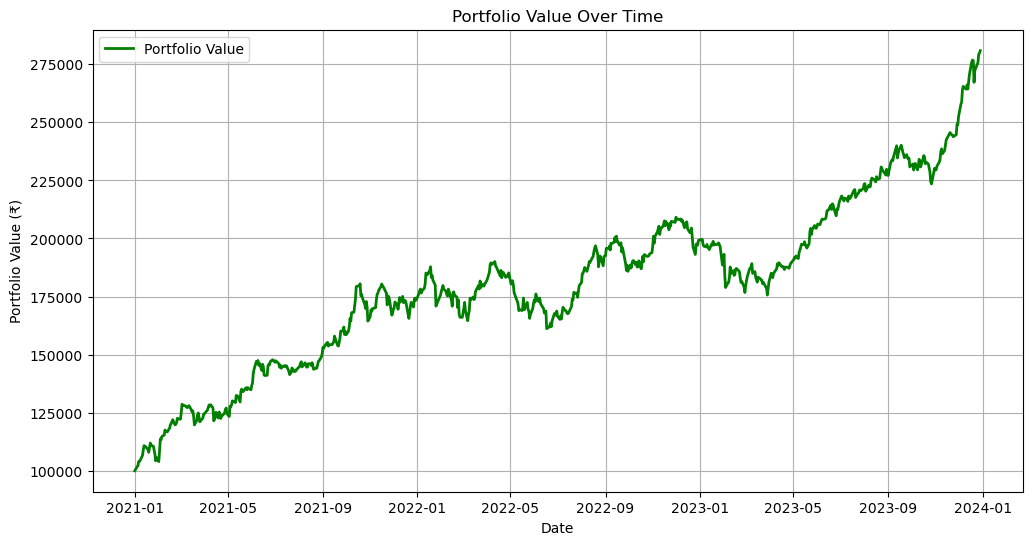

In [145]:
import matplotlib.pyplot as plt
#define the series containing value of portfolio
portfolio_series = pd.Series(portfolio_values, index=close_prices.index)
plt.figure(figsize=(12, 6))
plt.plot(portfolio_series, label='Portfolio Value', linewidth=2, color = 'green')
plt.title('Portfolio Value Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (₹)')
plt.grid(True)
plt.legend()
plt.show()

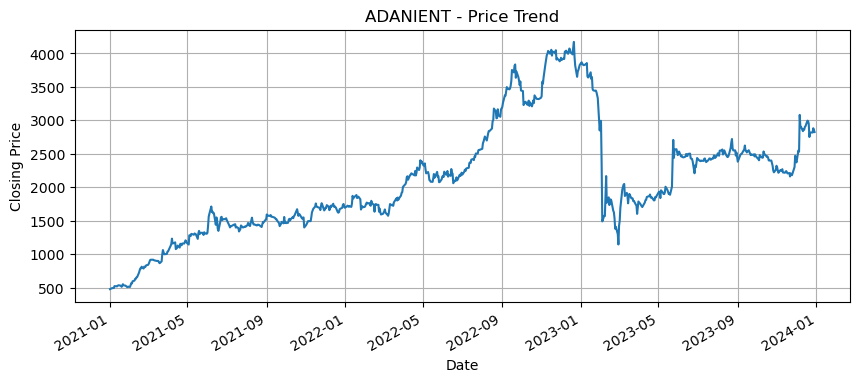

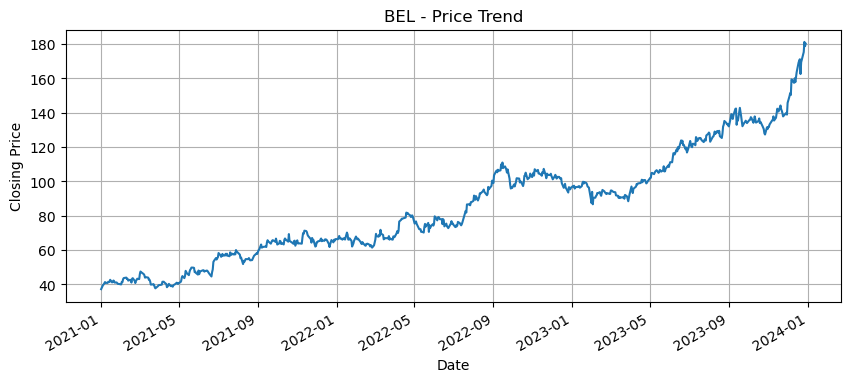

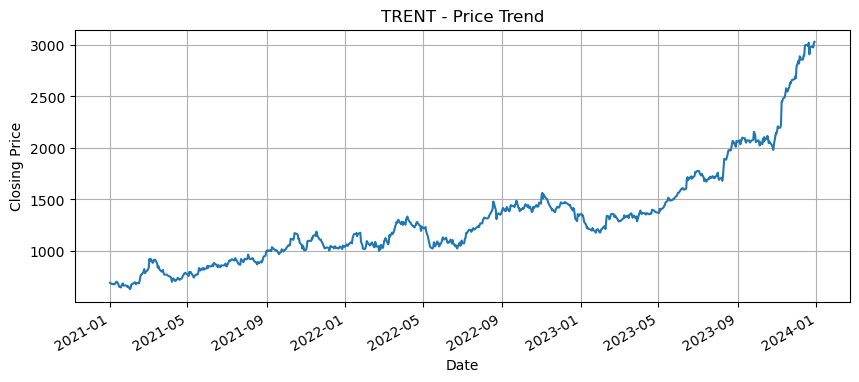

In [143]:
for stock in top_3_stocks.index:
    close_prices[stock].plot(figsize=(10, 4), title=f'{stock} - Price Trend')
    plt.xlabel('Date')
    plt.ylabel('Closing Price')
    plt.grid(True)
    plt.show()
